In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from tqdm import tqdm
import tomllib

import cdmprof

# Load config files
project_dir = Path(cdmprof.__file__).parent.parent
config_path = project_dir / "config.toml"
local_config_path = project_dir / "local_config.toml"

with open(config_path, "rb") as f:
    config = tomllib.load(f)
with open(local_config_path, "rb") as f:
    local_config = tomllib.load(f)

# Merge local_config into config
for key, value in local_config.items():
    if key in config and isinstance(config[key], dict):
        config[key].update(value)
    else:
        config[key] = value

%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
# Load halo data from config
data_dir = Path(config['path']['data'])
halos_rel = config['fitting']['halos']
halos_path = data_dir / halos_rel

print(f"Loading halos from: {halos_path}")

if halos_path.suffix in ['.hdf5', '.h5']:
    halos = cdmprof.data.load_from_hdf5(halos_path)
else:
    halos = cdmprof.load_from_folder(halos_path)

print(f"Loaded {halos.n_halos} halos")

Loading halos from: /Users/rstiskalek/Projects/CDMprofile/data/tng_particles/particles_099.hdf5
Loaded 904 halos


In [3]:
# Bin all halos (each halo gets its own rmin/rmax)
# n_sample: downsample each halo to this many particles (None = no downsampling)
n_sample = 10_000
binned = halos.bin(nbin=100, n_sample=n_sample, seed=42)
print(f"Binned data shape: {binned['bin_counts'].shape}")
print(f"bin_positions shape: {binned['bin_positions'].shape} (per halo)")
if n_sample is not None:
    print(f"Downsampled to {n_sample} particles per halo")

Binning:   0%|          | 0/904 [00:00<?, ?it/s]

Binning: 100%|██████████| 904/904 [00:00<00:00, 15734.56it/s]

Binned data shape: (904, 100)
bin_positions shape: (904, 100) (per halo)
Downsampled to 10000 particles per halo


In [10]:
# Compile a fitter for a density profile
# expr = "(a0 - exp(1/x))**2"
# expr = "1 / x**2"
expr = "1 / (x * (1 + x)**2)"
# expr = "pow(x,a0)"

fitter = cdmprof.compile_fitter(expr)
print(f"Expression: {expr}")
print(f"Number of parameters: {fitter.nparams} (Rs + {fitter.nfree} free)")

# Generate numpy function: rho_func(r, Rs, a0, a1, ...)
parser = cdmprof.SympyParser()
rho_func = parser.to_numpy(expr)
print(f"Generated numpy function with signature: rho_func(r, Rs, {', '.join(f'a{i}' for i in range(fitter.nfree))})")

Expression: 1 / (x * (1 + x)**2)
Number of parameters: 1 (Rs + 0 free)
Generated numpy function with signature: rho_func(r, Rs, )


In [11]:
# Fit all halos with multiple restarts and early stopping
optimizer = "neldermead"  # Options: "neldermead", "bobyqa", "sbplx"
print(f"Using optimizer: {optimizer}")

results = []
for i in tqdm(range(halos.n_halos), desc="Fitting"):
    result = fitter.fit_with_restarts(
        binned['bin_counts'][i],
        binned['bin_positions'][i],
        binned['rmin'][i],
        binned['rmax'][i],
        max_restarts=500,
        nconv_required=20,
        conv_rtol=1e-3,
        Rs_upper_factor=10,
        # conv_atol=0.5,
        # maxeval=2000,
        a_lower=-50,
        a_upper=50,
        optimizer=optimizer,
        # seed=42 + i,
    )
    result['halo_id'] = binned['halo_ids'][i]
    results.append(result)

print(f"\nFitted {len(results)} halos")

Using optimizer: neldermead


Fitting: 100%|██████████| 904/904 [00:00<00:00, 1409.90it/s]


Fitted 904 halos


In [12]:
# Summary statistics
# Filter out failed fits (params is None)
valid_results = [r for r in results if r['params'] is not None]
valid_indices = [i for i, r in enumerate(results) if r['params'] is not None]
print(f"Valid fits: {len(valid_results)}/{len(results)}")

if len(valid_results) > 0:
    losses = np.array([r['loss'] for r in valid_results])
    converged = np.array([r['converged'] for r in valid_results])
    confirmed = np.array([r['confirmed'] for r in valid_results])
    params = np.array([r['params'] for r in valid_results])
    neval = np.array([r['neval'] for r in valid_results])
    nrestart_used = np.array([r['nrestart_used'] for r in valid_results])
    nconv = np.array([r['nconv'] for r in valid_results])
    npart = binned['npart'][valid_indices]

    # Average loss: (loss / npart) averaged over halos
    avg_loss = np.mean(losses / npart)

    print(f"Converged: {converged.sum()}/{len(converged)}")
    print(f"Confirmed (converged to same min >= 5 times): {confirmed.sum()}/{len(confirmed)}")
    print(f"Loss: min={losses.min():.2f}, median={np.median(losses):.2f}, max={losses.max():.2f}")
    print(f"Average loss per particle (valid only): {avg_loss:.4f}")
    print(f"Total evals per halo: mean={neval.mean():.0f}, max={neval.max()}")
    print(f"Restarts used: mean={nrestart_used.mean():.1f}, max={nrestart_used.max()}")

    print(f"\nParameter ranges:")
    print(f"  Rs: [{params[:,0].min():.3f}, {params[:,0].max():.3f}]")
    for i in range(fitter.nfree):
        print(f"  a{i}: [{params[:,i+1].min():.3f}, {params[:,i+1].max():.3f}]")
else:
    print("No valid fits!")

# Statistics using loss_all (includes failed attempts)
print("\n--- Statistics using loss_all (all halos) ---")
losses_all = np.array([r['loss_all'] for r in results])
npart_all = binned['npart']

# Filter out failed optimizer runs (loss >= 1e29 indicates optimizer failure)
valid_mask = losses_all < 1e29
n_valid = valid_mask.sum()
n_failed = len(results) - n_valid
print(f"Halos with valid loss: {n_valid}/{len(results)}")

if n_valid > 0:
    loss_per_particle = losses_all[valid_mask] / npart_all[valid_mask]
    avg_loss_all = np.mean(loss_per_particle)
    print(f"Loss (all): min={losses_all[valid_mask].min():.2f}, "
          f"median={np.median(losses_all[valid_mask]):.2f}, "
          f"max={losses_all[valid_mask].max():.2f}")
    print(f"Average loss per particle (valid only): {avg_loss_all:.4f}")

    # Percentile imputation for failed halos
    failure_percentile = config['fitting'].get('failure_loss_percentile', 95)
    if failure_percentile > 0 and n_failed > 0:
        print(f"\n--- Percentile imputation (p={failure_percentile}) ---")
        imputed_loss = np.percentile(loss_per_particle, failure_percentile)
        print(f"Imputed loss per particle for {n_failed} failed halos: {imputed_loss:.4f}")
        
        # Create full array with imputed values for failed halos
        loss_per_particle_imputed = np.where(
            valid_mask,
            losses_all / npart_all,
            imputed_loss
        )
        avg_loss_imputed = np.mean(loss_per_particle_imputed)
        print(f"Average loss per particle (with imputation): {avg_loss_imputed:.4f}")

Valid fits: 904/904
Converged: 904/904
Confirmed (converged to same min >= 5 times): 904/904
Loss: min=73417.54, median=77315.93, max=89784.33
Average loss per particle (valid only): 7.8017
Total evals per halo: mean=376, max=432
Restarts used: mean=22.9, max=32

Parameter ranges:
  Rs: [6.322, 88.331]

--- Statistics using loss_all (all halos) ---
Halos with valid loss: 904/904
Loss (all): min=73417.54, median=77315.93, max=89784.33
Average loss per particle (valid only): 7.8017


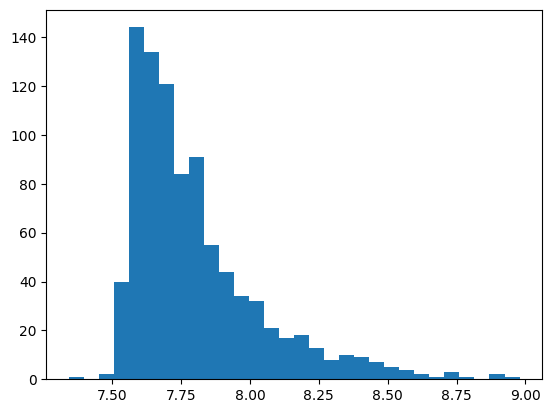

In [13]:
plt.figure()
plt.hist(losses_all[valid_mask] / npart_all[valid_mask], bins=30)

plt.show()

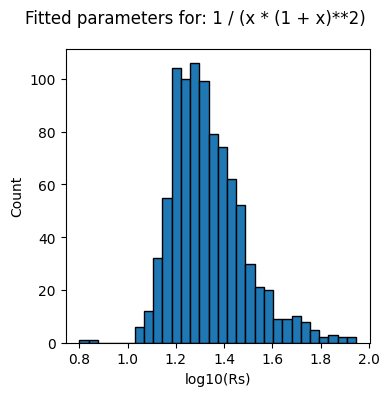

In [14]:
# Plot parameter distributions
ncols = 1 + fitter.nfree
fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 4))
if ncols == 1:
    axes = [axes]

axes[0].hist(np.log10(params[:, 0]), bins=30, edgecolor='black')
axes[0].set_xlabel('log10(Rs)')
axes[0].set_ylabel('Count')

for i in range(fitter.nfree):
    axes[i + 1].hist(params[:, i + 1], bins=30, edgecolor='black')
    axes[i + 1].set_xlabel(f'a{i}')

plt.suptitle(f"Fitted parameters for: {expr}")
plt.tight_layout()
plt.show()

Plotting Halo 9504 with Rs=33.51521
Plotting Halo 15830 with Rs=28.62557
Plotting Halo 20270 with Rs=27.80795
Plotting Halo 24570 with Rs=18.74269
Plotting Halo 28880 with Rs=25.23351
Plotting Halo 33323 with Rs=10.72856


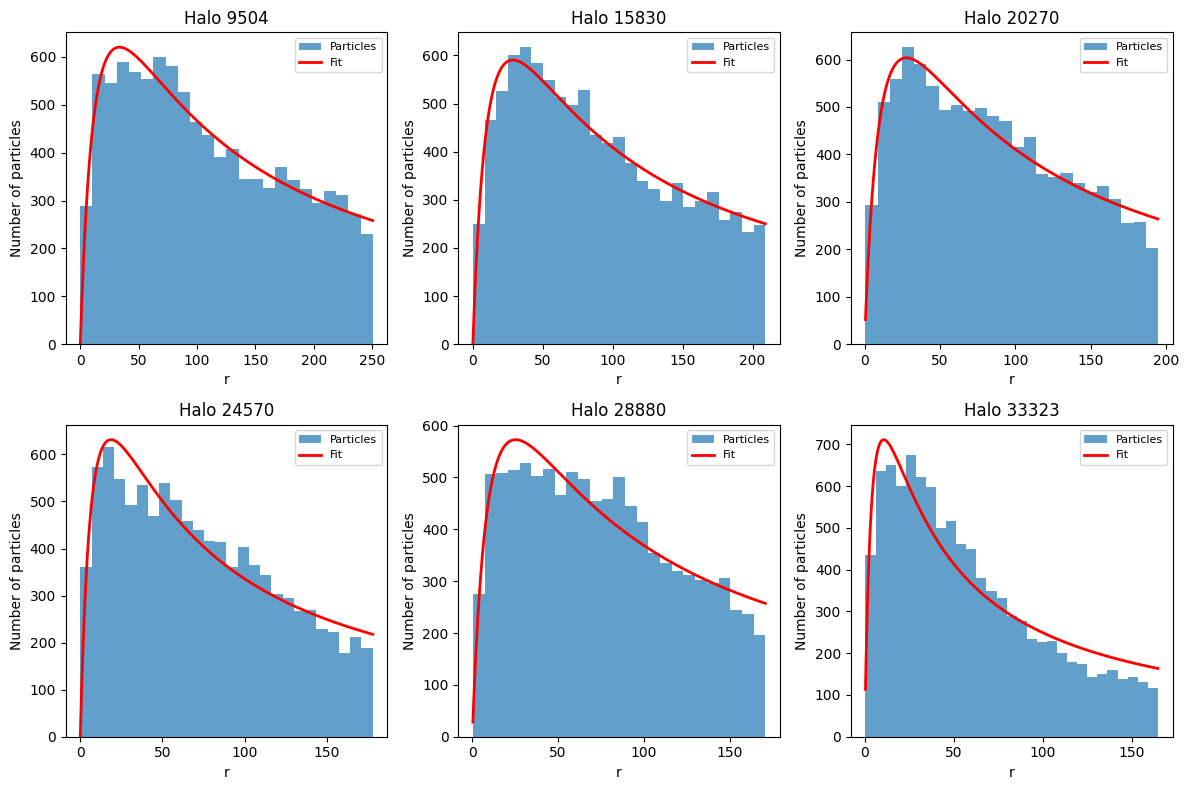

In [15]:
# Plot a few example fits with raw particle histograms
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

# Use only valid results (params is not None)
valid_indices = [i for i, r in enumerate(results) if r['params'] is not None]

for i, ax in enumerate(axes):
    idx = valid_indices[(i + 1) * (len(valid_indices) // 6)]  # Sample evenly from valid
    res = results[idx]
    halo_id = res['halo_id']
    
    # Raw particle radii from loader
    radii = halos[halo_id]
    
    # Fitted model parameters
    positions = binned['bin_positions'][idx]
    fit_params = res['params']  # [Rs, a0, a1, ...]
    
    # Print parameters
    param_str = f"Rs={fit_params[0]:.5f}"
    for j in range(fitter.nfree):
        param_str += f"; a{j}={fit_params[j+1]:.5f}"
    print(f"Plotting Halo {halo_id} with {param_str}")
    
    # Evaluate fitted profile using auto-generated numpy function
    r = np.logspace(np.log10(radii.min()), np.log10(radii.max()), 512)
    rho_fit = rho_func(r, *fit_params)
    
    # Plot histogram of raw radii (counts, not density)
    counts, bin_edges, _ = ax.hist(radii, bins="auto", alpha=0.7, label='Particles')
    
    # Overlay fitted density scaled to particle counts
    # Scale: rho * r^2 gives radial distribution, then normalize to total particles
    rho_scaled = rho_fit * r**2
    rho_scaled = rho_scaled / np.trapezoid(rho_scaled, r) * len(radii) * np.mean(np.diff(bin_edges))
    ax.plot(r, rho_scaled, 'r-', lw=2, label='Fit')
    
    ax.set_xlabel('r')
    ax.set_ylabel('Number of particles')
    ax.set_title(f"Halo {halo_id}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

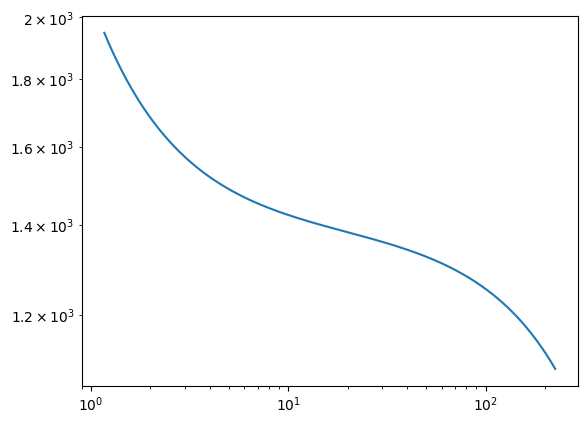

In [48]:
plt.figure()
# plt.plot(r, rho_fit)
plt.plot(r, rho_scaled)

plt.xscale("log")
plt.yscale("log")

plt.show()